In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e8/train.csv
/kaggle/input/competitions/playground-series-s6e8/test.csv


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform

print("Completed loading libraries ..")

Completed loading libraries ..




Dimensions of the DataFrame
(691369, 14)

--------------------------------------------------------------------------------

Summary of the DataFrame's structure
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress

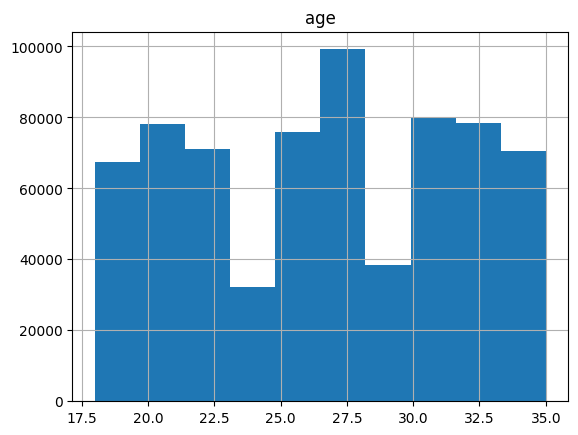


--------------------------------------------------------------------------------

daily_screen_time_hours skewness: -0.13197209083432848
Filling NaNs in 'daily_screen_time_hours' with mean value: 7.640865487855051


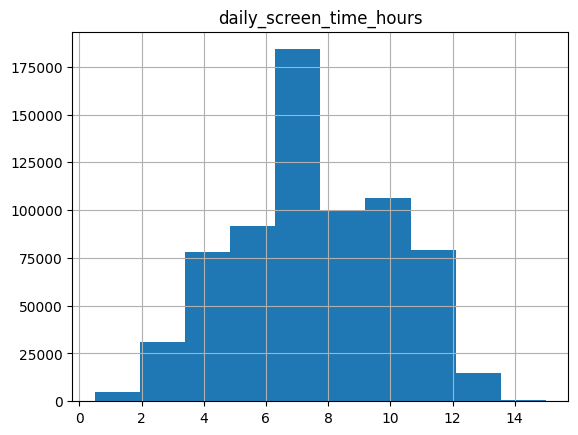


--------------------------------------------------------------------------------

social_media_hours skewness: 0.468081393910621
Filling NaNs in 'social_media_hours' with mean value: 2.4710382077384314


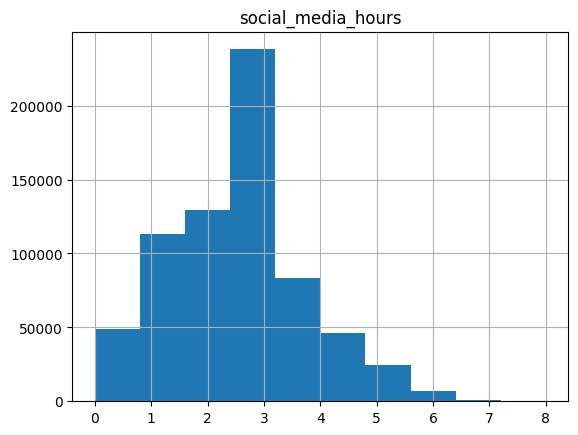


--------------------------------------------------------------------------------

gaming_hours skewness: 0.5447396028536303
Filling NaNs in 'gaming_hours' with median value: 1.33


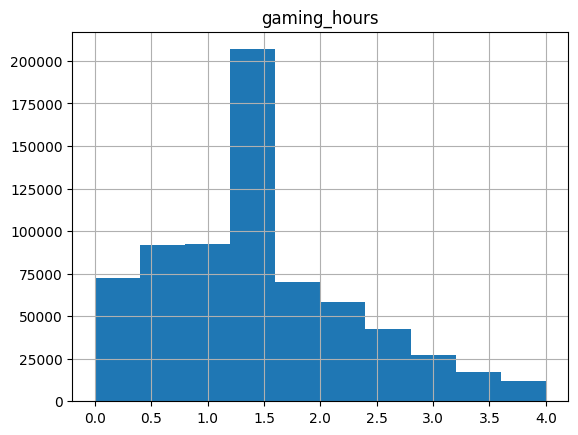


--------------------------------------------------------------------------------

work_study_hours skewness: 0.5634570530721745
Filling NaNs in 'work_study_hours' with median value: 2.2


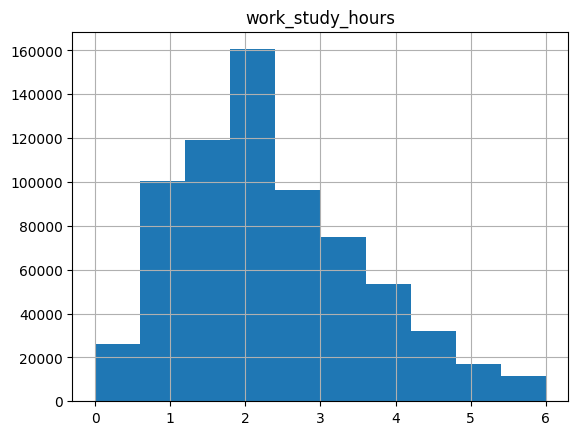


--------------------------------------------------------------------------------

sleep_hours skewness: -0.00658666980407133
Filling NaNs in 'sleep_hours' with mean value: 6.804334097503589


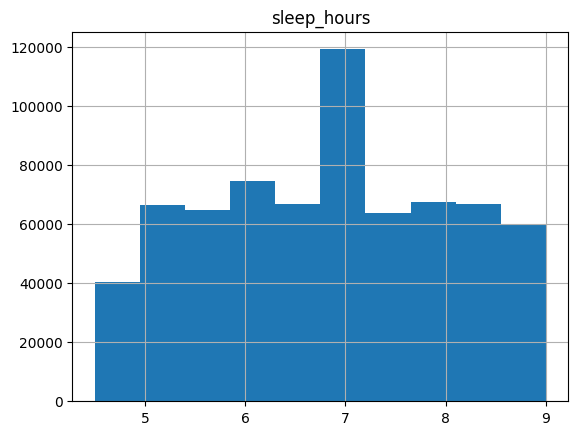


--------------------------------------------------------------------------------

notifications_per_day skewness: -0.20653513389695957
Filling NaNs in 'notifications_per_day' with mean value: 145.89489968498762


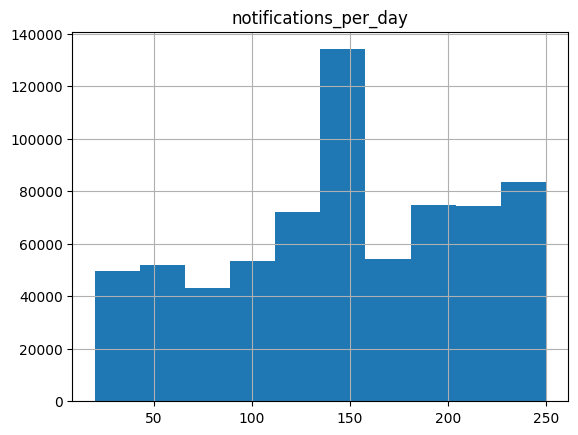


--------------------------------------------------------------------------------

app_opens_per_day skewness: -0.126463220385457
Filling NaNs in 'app_opens_per_day' with mean value: 102.63678092028448


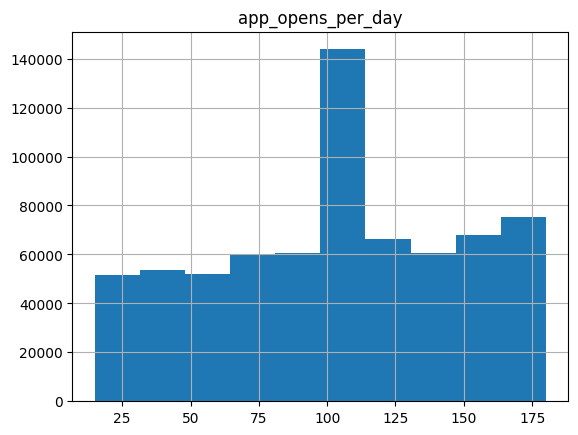


--------------------------------------------------------------------------------

weekend_screen_time skewness: -0.06340829123835504
Filling NaNs in 'weekend_screen_time' with mean value: 9.479866442778084


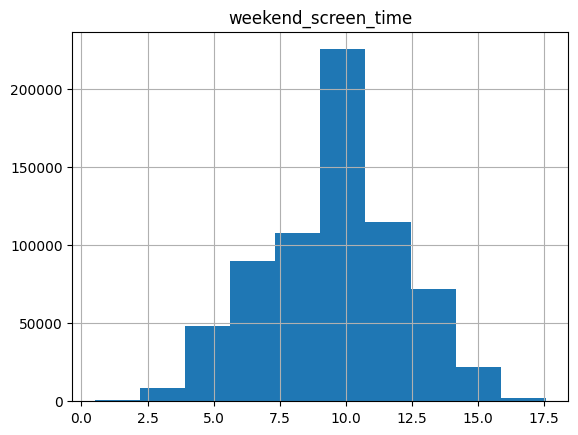


--------------------------------------------------------------------------------


Filling NaN values in categorical features with mode

Filling NaN in 'gender' with mode: Male

Filling NaN in 'stress_level' with mode: High

Filling NaN in 'academic_work_impact' with mode: Yes


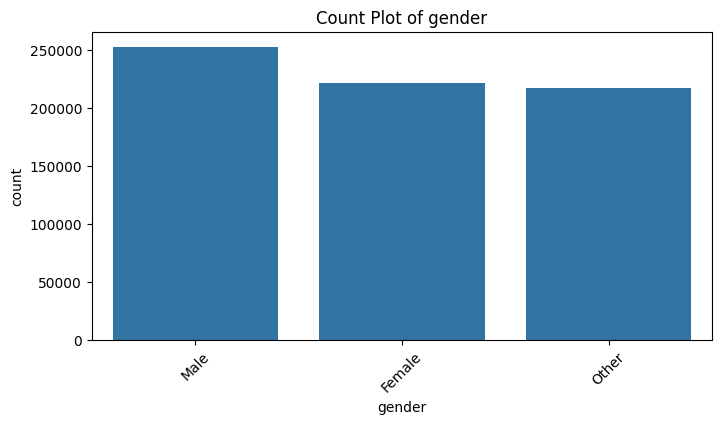


--------------------------------------------------------------------------------


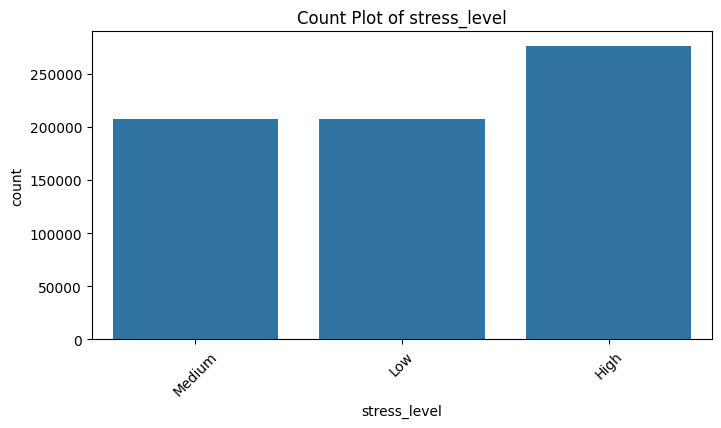


--------------------------------------------------------------------------------


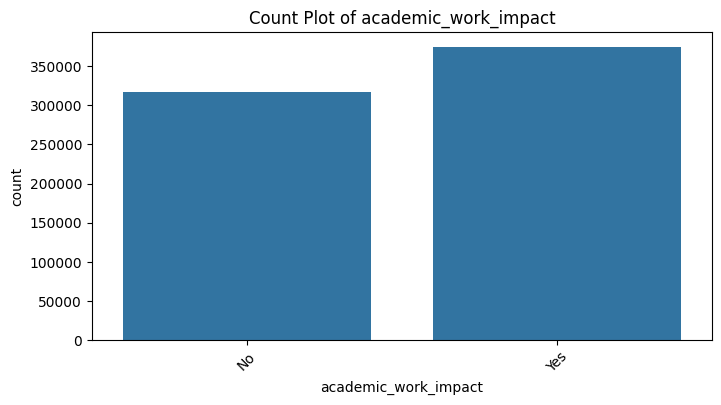


--------------------------------------------------------------------------------

Total integer features with zero: 0
1. social_media_hours (float64) - Zero count: 12
2. gaming_hours (float64) - Zero count: 110
3. work_study_hours (float64) - Zero count: 5

Total float features with zero: 3
gender (object):
gender
Male      252696
Female    221595
Other     217078
Name: count, dtype: int64

******************************

stress_level (object):
stress_level
High      276021
Low       207783
Medium    207565
Name: count, dtype: int64

******************************

academic_work_impact (object):
academic_work_impact
Yes    374790
No     316579
Name: count, dtype: int64

******************************



In [3]:

# Load train data
train_path = '/kaggle/input/competitions/playground-series-s6e8/train.csv'
df = pd.read_csv(train_path)

# Basic info and preview
print("\n" + "="*80 + "\n")
print("Dimensions of the DataFrame")
print(df.shape)
print("\n" + "-"*80 )
print("\nSummary of the DataFrame's structure")
print(df.info())
print("\n" + "-"*80 )
print("\nTotal number of missing data")
print(df.isna().sum())
print("\n" + "="*80)

# Automate filling NaN for numerical features based on skewness
print("\nAnalyzing Numerical Features for Skewness and Filling NaNs Accordingly\n")
for col in df.columns[1:-1]:
    if df[col].dtype != 'object':
        sk = df[col].skew()
        print(f'{col} skewness: {sk}')
        if -0.5 < sk < 0.5:
            fill_value = df[col].mean()
            method = 'mean'
        else:
            fill_value = df[col].median()
            method = 'median'
        print(f"Filling NaNs in '{col}' with {method} value: {fill_value}")
        df[col] = df[col].fillna(fill_value)
        # Plot histogram
        plt.title(col)
        df[col].hist()
        plt.show()
        print("\n" + "-"*80 + "\n")

# Automate filling NaN for categorical features with mode
print("\nFilling NaN values in categorical features with mode")
for col in df.select_dtypes(include='object').columns:
    mode_value = df[col].mode()[0]
    print("\n" + "="*80)
    print(f"Filling NaN in '{col}' with mode: {mode_value}")
    df[col] = df[col].fillna(mode_value)

# Loop through categorical columns and plot count plots
for col in df.select_dtypes(include='object').columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.show()
    print("\n" + "-"*80)
    
# Check for zero values in numerical features
j = 0
for col in df.columns[1:-1]:
    if df[col].dtype == 'int64' and (df[col] == 0).sum() != 0:
        print(f"{j+1}. {col} ({df[col].dtype}) - Zero count: {(df[col] == 0).sum()}")
        j += 1
print(f"\nTotal integer features with zero: {j}")

j = 0
for col in df.columns[1:-1]:
    if df[col].dtype == 'float64' and (df[col] == 0).sum() != 0:
        print(f"{j+1}. {col} ({df[col].dtype}) - Zero count: {(df[col] == 0).sum()}")
        j += 1
print(f"\nTotal float features with zero: {j}")

# Explore object columns
for col in df.select_dtypes(include='object').columns:
    print(f"{col} ({df[col].dtype}):")
    print(df[col].value_counts())
    print("\n" + "*"*30 + "\n")





Dimensions of the DataFrame
(296302, 13)

--------------------------------------------------------------------------------

Summary of the DataFrame's structure
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296302 entries, 0 to 296301
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       296302 non-null  int64  
 1   age                      279164 non-null  float64
 2   daily_screen_time_hours  263514 non-null  float64
 3   social_media_hours       248905 non-null  float64
 4   gaming_hours             236882 non-null  float64
 5   work_study_hours         268525 non-null  float64
 6   sleep_hours              273847 non-null  float64
 7   notifications_per_day    262081 non-null  float64
 8   app_opens_per_day        270597 non-null  float64
 9   weekend_screen_time      245605 non-null  float64
 10  gender                   282090 non-null  object 
 11  stress

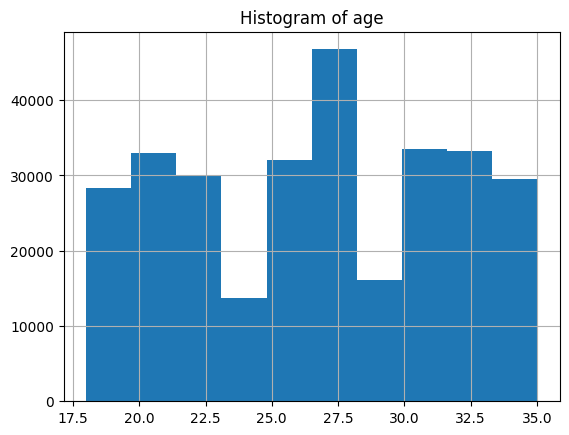


***************************************************************************

daily_screen_time_hours skewness: -0.1308451686597246
Filled NaN in daily_screen_time_hours with mean: 7.640770737038639


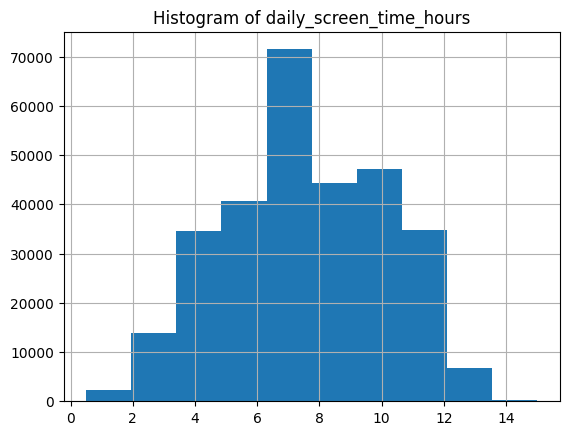


***************************************************************************

social_media_hours skewness: 0.4717692499494669
Filled NaN in social_media_hours with mean: 2.4712239609489557


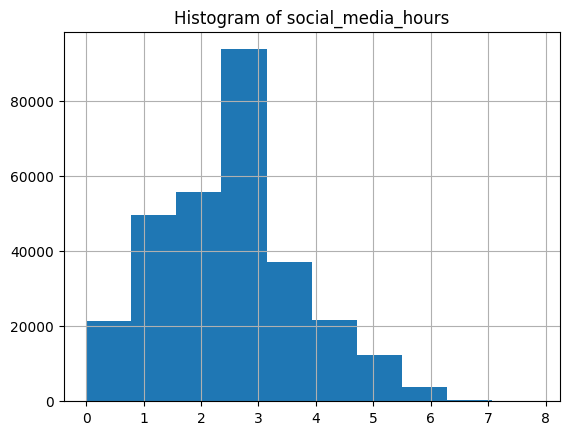


***************************************************************************

gaming_hours skewness: 0.5450086314908379
Filled NaN in gaming_hours with median: 1.33


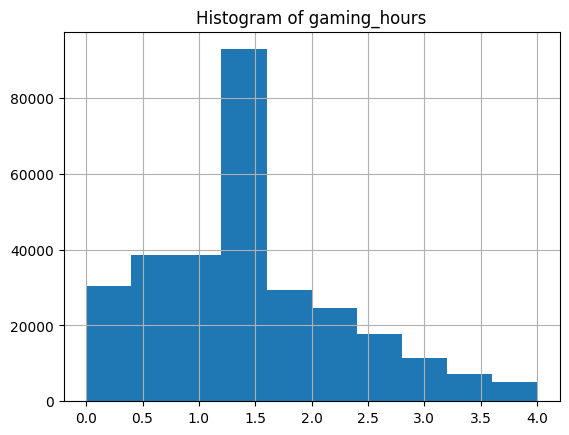


***************************************************************************

work_study_hours skewness: 0.5623996855302822
Filled NaN in work_study_hours with median: 2.2


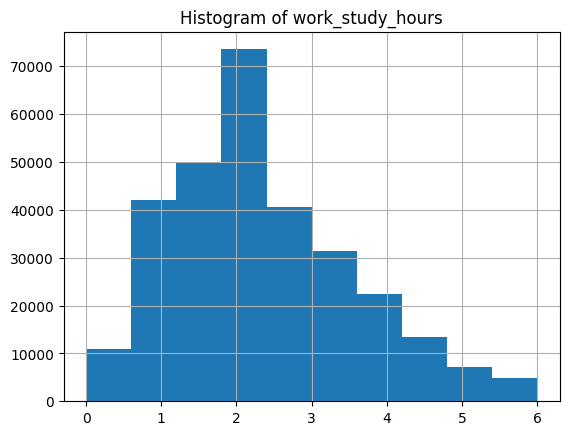


***************************************************************************

sleep_hours skewness: -0.007079753831678084
Filled NaN in sleep_hours with mean: 6.801704309340617


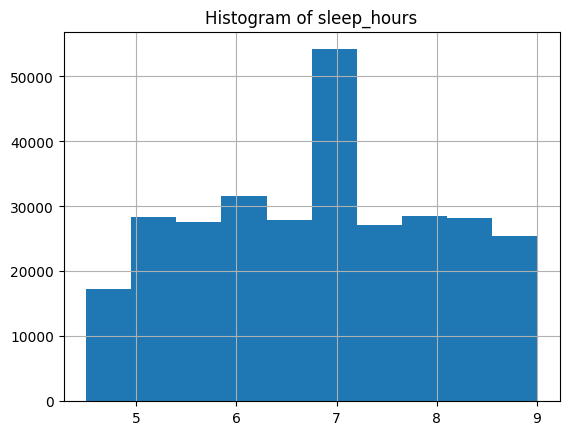


***************************************************************************

notifications_per_day skewness: -0.2028126675993759
Filled NaN in notifications_per_day with mean: 145.74806643747544


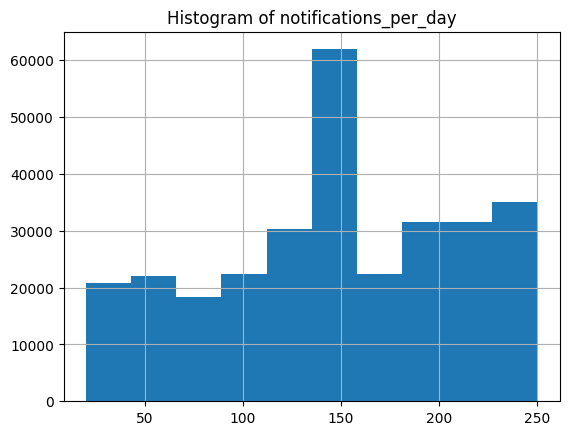


***************************************************************************

app_opens_per_day skewness: -0.12534293278560346
Filled NaN in app_opens_per_day with mean: 102.65621570083925


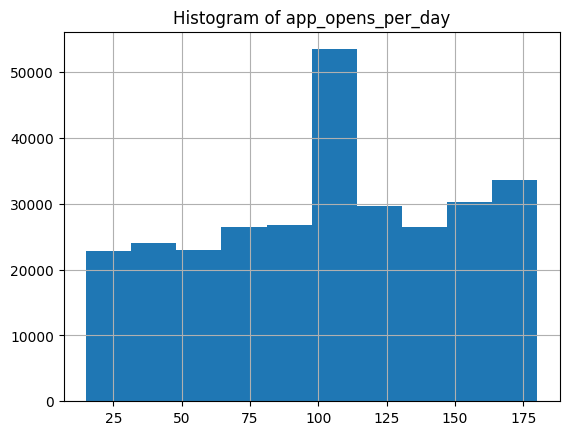


***************************************************************************

weekend_screen_time skewness: -0.06518549027941012
Filled NaN in weekend_screen_time with mean: 9.474574975672324


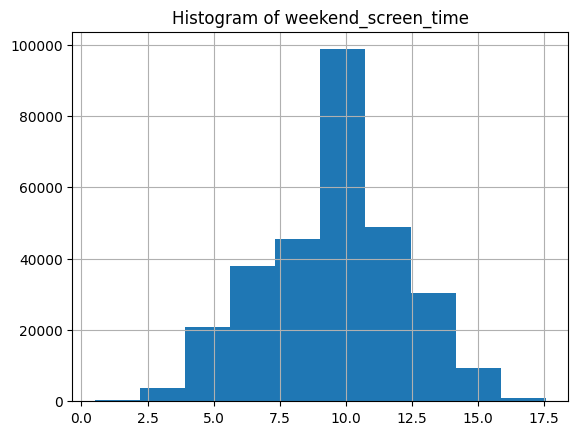


***************************************************************************

Categorical Data Visualization for Test Data


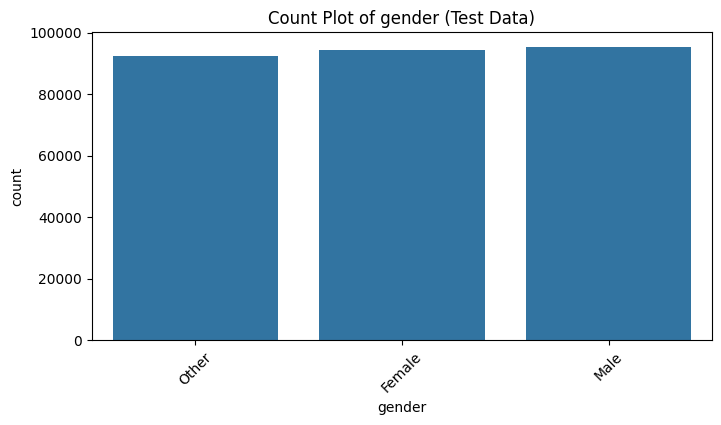

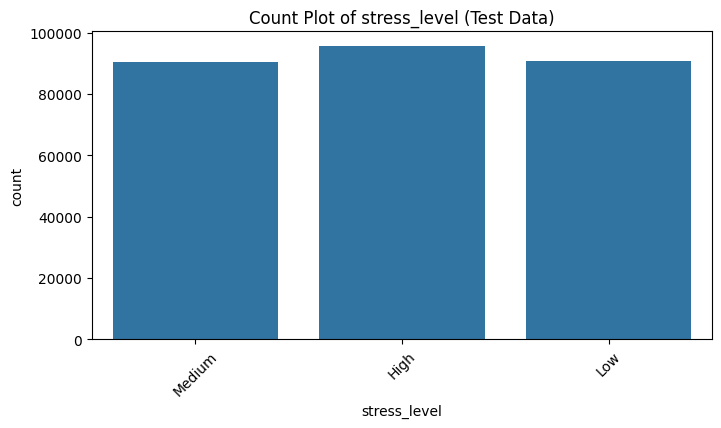

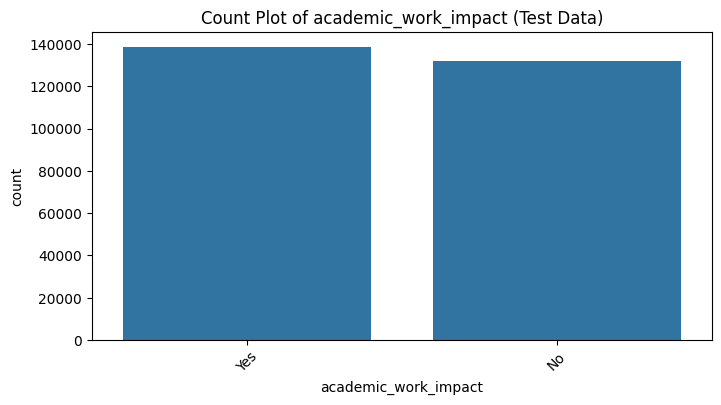


Total integer features with zero in test: 0
1. social_media_hours (float64) - Zero count: 4
2. gaming_hours (float64) - Zero count: 40
3. work_study_hours (float64) - Zero count: 1

Total float features with zero in test: 3
gender (object):
gender
Male      95357
Female    94295
Other     92438
Name: count, dtype: int64

------------------------------

stress_level (object):
stress_level
High      95622
Low       90746
Medium    90308
Name: count, dtype: int64

------------------------------

academic_work_impact (object):
academic_work_impact
Yes    138694
No     131887
Name: count, dtype: int64

------------------------------



In [4]:
# Load test data
test_path = '/kaggle/input/competitions/playground-series-s6e8/test.csv'
test = pd.read_csv(test_path)

# Similar analysis and filling for test data
# Basic info and preview
print("\n" + "="*80 + "\n")
print("Dimensions of the DataFrame")
print(test.shape)
print("\n" + "-"*80 )
print("\nSummary of the DataFrame's structure")
print(test.info())
print("\n" + "-"*80 )
print("\nTotal number of missing data")
print(test.isna().sum())
print("\n" + "="*80)

# --- Numerical Data Analysis and NaN Filling for Test Data ---
print("Numerical Data Analysis and NaN Filling for Test Data")
# --- Numerical Data Analysis and NaN Filling for Test Data ---
print("Numerical Data Analysis and NaN Filling for Test Data")
for col in test.columns[1:]:
    if np.issubdtype(test[col].dtype, np.number):
        sk = test[col].skew()
        print(f'{col} skewness: {sk}')
        # Decide whether to fill NaNs with mean or median
        if -0.5 < sk < 0.5:
            test[col] = test[col].fillna(test[col].mean())
            print(f"Filled NaN in {col} with mean: {test[col].mean()}")
        else:
            test[col] = test[col].fillna(test[col].median())
            print(f"Filled NaN in {col} with median: {test[col].median()}")
        # Plot histogram
        plt.figure()
        test[col].hist()
        plt.title(f'Histogram of {col}')
        plt.show()
        print("\n" + "*"*75 + "\n")
        
# --- Categorical Data Visualization ---
print("Categorical Data Visualization for Test Data")

for col in test.select_dtypes(include='object').columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=test)
    plt.title(f'Count Plot of {col} (Test Data)')
    plt.xticks(rotation=45)
    plt.show()

# --- Zero Value Check in Test Data ---
j = 0
for col in test.columns[1:]:
    if (test[col].dtype == 'int64') and (test[col] == 0).sum() != 0:
        print(f"{j+1}. {col} ({test[col].dtype}) - Zero count: {(test[col] == 0).sum()}")
        j += 1
print(f"\nTotal integer features with zero in test: {j}")

j = 0
for col in test.columns[1:]:
    if (test[col].dtype == 'float64') and (test[col] == 0).sum() != 0:
        print(f"{j+1}. {col} ({test[col].dtype}) - Zero count: {(test[col] == 0).sum()}")
        j += 1
print(f"\nTotal float features with zero in test: {j}")

# Explore object columns
for col in test.select_dtypes(include='object').columns:
    print(f"{col} ({test[col].dtype}):")
    print(test[col].value_counts())
    print("\n" + "-"*30 + "\n")


In [5]:
import os
import time
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score, 
    roc_curve, 
    precision_recall_curve, 
    auc, 
    confusion_matrix,
    log_loss,
    f1_score,
    precision_score,
    recall_score
)

import lightgbm as lgb
from lightgbm import LGBMClassifier
import optuna

# Hide unnecessary warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# ==============================================================================
# FEATURE ENGINEERING HELPER FUNCTIONS
# ==============================================================================
def add_group_aggregations(train_df, test_df, group_cols=['gender', 'stress_level']):
    """Calculates mean & std of key numericals within categorical cohorts."""
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    target_numericals = ["daily_screen_time_hours", "social_media_hours", "app_opens_per_day"]
    target_numericals = [col for col in target_numericals if col in train_df.columns]
    
    for col in target_numericals:
        group_stats = train_df.groupby(group_cols)[col].agg(['mean', 'std']).reset_index()
        group_stats.columns = group_cols + [f"{col}_grp_mean", f"{col}_grp_std"]
        
        train_df = train_df.merge(group_stats, on=group_cols, how='left')
        test_df = test_df.merge(group_stats, on=group_cols, how='left')
        
        train_df[f"{col}_zscore_in_grp"] = (train_df[col] - train_df[f"{col}_grp_mean"]) / (train_df[f"{col}_grp_std"] + 1e-6)
        test_df[f"{col}_zscore_in_grp"] = (test_df[col] - test_df[f"{col}_grp_mean"]) / (test_df[f"{col}_grp_std"] + 1e-6)
        
    return train_df, test_df

def feature_engineering(train_df, test_df):
    def process_basic(df):
        df = df.copy()
        eps = 1e-6

        if "social_media_hours" in df.columns and "gaming_hours" in df.columns:
            df["entertainment_hours"] = df["social_media_hours"] + df["gaming_hours"]
        
        if "daily_screen_time_hours" in df.columns:
            if "social_media_hours" in df.columns:
                df["social_ratio"] = df["social_media_hours"] / (df["daily_screen_time_hours"] + eps)
            if "gaming_hours" in df.columns:
                df["gaming_ratio"] = df["gaming_hours"] / (df["daily_screen_time_hours"] + eps)
            if "weekend_screen_time" in df.columns:
                df["weekend_extra"] = df["weekend_screen_time"] - df["daily_screen_time_hours"]
                df["weekend_screen_multiplier"] = df["weekend_screen_time"] / (df["daily_screen_time_hours"] + eps)
            if "work_study_hours" in df.columns:
                df["productive_screen_ratio"] = df["work_study_hours"] / (df["daily_screen_time_hours"] + eps)
            if "notifications_per_day" in df.columns:
                df["notifications_per_screen_hour"] = df["notifications_per_day"] / (df["daily_screen_time_hours"] + eps)
            if "app_opens_per_day" in df.columns:
                df["minutes_per_app_open"] = (df["daily_screen_time_hours"] * 60) / (df["app_opens_per_day"] + eps)

        if "sleep_hours" in df.columns:
            df["sleep_deficit"] = 8 - df["sleep_hours"]
            df["active_hours"] = 24 - df["sleep_hours"]
            if "daily_screen_time_hours" in df.columns:
                df["screen_time_to_awake_ratio"] = df["daily_screen_time_hours"] / (df["active_hours"] + eps)

        if "sleep_hours" in df.columns and "daily_screen_time_hours" in df.columns:
            df["high_screen_low_sleep_flag"] = ((df["sleep_hours"] < 6) & (df["daily_screen_time_hours"] > 6)).astype(int)
        
        if "notifications_per_day" in df.columns and "app_opens_per_day" in df.columns:
            df["compulsive_checking_score"] = np.log1p(df["notifications_per_day"]) * np.log1p(df["app_opens_per_day"])

        for col in ["notifications_per_day", "app_opens_per_day", "social_media_hours"]:
            if col in df.columns:
                df[f"{col}_log"] = np.log1p(df[col])

        return df

    train_df = process_basic(train_df)
    test_df = process_basic(test_df)
    
    if "gender" in train_df.columns and "stress_level" in train_df.columns:
        train_df, test_df = add_group_aggregations(train_df, test_df, group_cols=['gender', 'stress_level'])

    return train_df, test_df

# ==============================================================================
# RUN FEATURE ENGINEERING & DATA PREPARATION
# ==============================================================================
# Assume `df` and `test` are already loaded DataFrames
df, test = feature_engineering(df, test)

test_ids = test['id'] if 'id' in test.columns else None
df = df.drop(columns=['id'], errors='ignore')
test = test.drop(columns=['id'], errors='ignore')

TARGET_COL = 'addicted_label'

# Encode Categorical Features explicitly as 'category' dtype for LightGBM
categorical_cols = ['gender', 'stress_level', 'academic_work_impact']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')
        test[col] = test[col].astype('category')

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]
test = test[X.columns]

# ==============================================================================
# OPTUNA HYPERPARAMETER TUNING WITH PRUNING
# ==============================================================================
TOTAL_TRIALS = 30
start_time_optuna = time.time()

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'n_estimators': 3000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.8),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.9, 1.3)
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
        X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]

        model = LGBMClassifier(**params)
        
        # Native LightGBM early stopping callback
        early_stopping = lgb.early_stopping(stopping_rounds=100, verbose=False)

        model.fit(
            X_train_fold,
            y_train_fold,
            eval_set=[(X_val_fold, y_val_fold)],
            eval_metric='auc',
            callbacks=[early_stopping]
        )

        oof_preds[val_idx] = model.predict_proba(X_val_fold)[:, 1]

    return roc_auc_score(y, oof_preds)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
        X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]

        model = LGBMClassifier(**params)
        
        pruning_callback = optuna.integration.LightGBMPruningCallback(trial, "auc")
        early_stopping = lgb.early_stopping(stopping_rounds=100, verbose=False)

        model.fit(
            X_train_fold,
            y_train_fold,
            eval_set=[(X_val_fold, y_val_fold)],
            eval_metric='auc',
            callbacks=[early_stopping, pruning_callback]
        )

        oof_preds[val_idx] = model.predict_proba(X_val_fold)[:, 1]

    return roc_auc_score(y, oof_preds)

def print_trial_analytics(study, trial):
    elapsed = time.time() - start_time_optuna
    is_best = trial.value == study.best_value
    best_str = "⭐ NEW BEST!" if is_best else f"(Best: {study.best_value:.6f})"
    
    print(
        f"Trial {trial.number + 1:02d}/{TOTAL_TRIALS:02d} | "
        f"OOF ROC-AUC: {trial.value:.6f} | "
        f"Elapsed: {elapsed:.1f}s | {best_str}"
    )

print("\n" + "="*85)
print(f" STARTING OPTUNA BAYESIAN HYPERPARAMETER OPTIMIZATION ".center(85, "="))
print("="*85)

study = optuna.create_study(
    direction="maximize", 
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=TOTAL_TRIALS, callbacks=[print_trial_analytics])

best_params = study.best_params
print("\n" + "="*85)
print("OPTUNA TUNING COMPLETE")
print(f"Best OOF ROC-AUC Score Achieved: {study.best_value:.6f}")
print("Best Hyperparameters:")
for param, val in best_params.items():
    print(f" - {param}: {val}")
print("="*85)

# ==============================================================================
# MULTI-SEED ENSEMBLE TRAINING
# ==============================================================================
SEEDS = [42, 99, 333, 2024]
all_test_preds = np.zeros(len(test))
all_oof_preds = np.zeros(len(X))
seed_scores = []

all_prob_true, all_prob_pred = [], []

for seed in SEEDS:
    print("\n" + "="*85)
    print(f" TRAINING SEED {seed} ".center(85, "="))
    print("="*85)

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)
    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(test))

    print(f"{'Fold':<6} | {'ROC-AUC':<9} | {'Log-Loss':<9} | {'F1-Score':<9} | {'Best Iter':<9}")
    print("-" * 60)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
        X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]

        model = LGBMClassifier(
            **best_params,
            n_estimators=5000,
            objective='binary',
            random_state=seed,
            verbosity=-1
        )

        model.fit(
            X_train_fold,
            y_train_fold,
            eval_set=[(X_val_fold, y_val_fold)],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(stopping_rounds=150, verbose=False)]
        )

        val_pred = model.predict_proba(X_val_fold)[:, 1]
        oof_preds[val_idx] = val_pred

        fold_auc = roc_auc_score(y_val_fold, val_pred)
        fold_logloss = log_loss(y_val_fold, val_pred)
        fold_f1 = f1_score(y_val_fold, (val_pred >= 0.5).astype(int), zero_division=0)
        best_iter = model.best_iteration_

        print(f"Fold {fold+1:<2} | {fold_auc:<9.6f} | {fold_logloss:<9.6f} | {fold_f1:<9.6f} | {best_iter:<9}")

        test_preds += model.predict_proba(test)[:, 1] / skf.n_splits

    seed_auc = roc_auc_score(y, oof_preds)
    seed_logloss = log_loss(y, oof_preds)
    seed_f1 = f1_score(y, (oof_preds >= 0.5).astype(int))
    seed_scores.append(seed_auc)

    print("-" * 60)
    print(f"SEED {seed} SUMMARY: OOF ROC-AUC = {seed_auc:.6f} | Log-Loss = {seed_logloss:.6f}")

    all_oof_preds += oof_preds / len(SEEDS)
    all_test_preds += test_preds / len(SEEDS)

# ==============================================================================
# THRESHOLD OPTIMIZATION
# ==============================================================================
print("\n" + "="*85)
print(f" OPTIMIZING DECISION THRESHOLD FOR F1-SCORE ".center(85, "="))
print("="*85)

thresholds = np.linspace(0.01, 0.99, 500)
f1_scores = [f1_score(y, (all_oof_preds >= t).astype(int), zero_division=0) for t in thresholds]

best_threshold_grid = thresholds[np.argmax(f1_scores)]

def loss_func(thresh):
    t = thresh[0]
    preds = (all_oof_preds >= t).astype(int)
    return -f1_score(y, preds, zero_division=0)

res = minimize(loss_func, x0=[best_threshold_grid], method='Powell', bounds=[(0.01, 0.99)])
optimal_threshold = float(res.x[0]) if res.success else best_threshold_grid
optimal_f1 = -res.fun if res.success else np.max(f1_scores)
default_f1 = f1_score(y, (all_oof_preds >= 0.5).astype(int))

print(f"Default Threshold (0.5000) OOF F1-Score : {default_f1:.6f}")
print(f"Optimal Threshold ({optimal_threshold:.4f}) OOF F1-Score : {optimal_f1:.6f}")
print(f"F1-Score Absolute Improvement          : +{optimal_f1 - default_f1:.6f}")

# ==============================================================================
# FINAL EVALUATION & GENERATE SUBMISSION
# ==============================================================================
final_auc = roc_auc_score(y, all_oof_preds)
final_logloss = log_loss(y, all_oof_preds)

print("\n" + "="*85)
print(f" FINAL ENSEMBLE SUMMARY ".center(85, "="))
print("="*85)
print(f"Averaged OOF ROC-AUC        : {final_auc:.6f}")
print(f"Averaged OOF Log-Loss       : {final_logloss:.6f}")
print(f"Optimal Decision Threshold : {optimal_threshold:.4f}")
print(f"Maximized OOF F1-Score      : {optimal_f1:.6f}")
print("-" * 85)

# Save Predictions
submission = pd.DataFrame({
    "id": test_ids,
    "addicted_label": all_test_preds
})

submission.to_csv("submission.csv", index=False)
print("\nFirst 10 Submission rows:")
print(submission.head(10))


================ STARTING OPTUNA BAYESIAN HYPERPARAMETER OPTIMIZATION ===============
Trial 01/30 | OOF ROC-AUC: 0.963592 | Elapsed: 872.9s | ⭐ NEW BEST!
Trial 02/30 | OOF ROC-AUC: 0.963226 | Elapsed: 1497.5s | (Best: 0.963592)
Trial 03/30 | OOF ROC-AUC: 0.963060 | Elapsed: 2283.7s | (Best: 0.963592)
Trial 04/30 | OOF ROC-AUC: 0.958277 | Elapsed: 2874.4s | (Best: 0.963592)
Trial 05/30 | OOF ROC-AUC: 0.961910 | Elapsed: 3710.7s | (Best: 0.963592)
Trial 06/30 | OOF ROC-AUC: 0.963789 | Elapsed: 4626.7s | ⭐ NEW BEST!
Trial 07/30 | OOF ROC-AUC: 0.959755 | Elapsed: 5322.2s | (Best: 0.963789)
Trial 08/30 | OOF ROC-AUC: 0.962784 | Elapsed: 6085.5s | (Best: 0.963789)
Trial 09/30 | OOF ROC-AUC: 0.961503 | Elapsed: 6955.3s | (Best: 0.963789)
Trial 10/30 | OOF ROC-AUC: 0.960124 | Elapsed: 7623.3s | (Best: 0.963789)
Trial 11/30 | OOF ROC-AUC: 0.963900 | Elapsed: 8291.0s | ⭐ NEW BEST!
Trial 12/30 | OOF ROC-AUC: 0.963892 | Elapsed: 8948.8s | (Best: 0.963900)
Trial 13/30 | OOF ROC-AUC: 0.963918 | Ela